In [1]:
import pygris
import osmnx as ox
import pandas as pd
from shapely.geometry import Point, Polygon
import numpy as np
from tqdm import tqdm
import geopandas as gpd
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import networkx as nx
from utils import construct_block_graph, evaluate_zoning, haversine_distance
import h3
import json

### Read the city map and road network

In [2]:
# Read the road network for Chattanooga
G = ox.load_graphml('data/chatt_graph.graphml')

# Read the city boundary
city = "Chattanooga, Tennessee, USA"
boundary_chatt = ox.geocode_to_gdf(city).geometry.iloc[0]

### Mapping the city to the H3 system

In [3]:
# H3 resolution for hexagons
resolution = 7

hexagons = h3.geo_to_cells(boundary_chatt, resolution)
hex_polygons = []
for hexagon in hexagons:
    hex_polygons.append(Polygon(h3.cell_to_boundary(hexagon)))

# Create a GeoDataFrame from the hexagons
hex_gdf = gpd.GeoDataFrame(geometry=hex_polygons)

hex_gdf['id'] = hexagons
hex_gdf.set_index('id', inplace=True)
for hexid, row in hex_gdf.iterrows():
    
    # Calculate the centroid of each hexagon
    hex_gdf.at[hexid, 'centroid_lat'] = row.geometry.centroid.x
    hex_gdf.at[hexid, 'centroid_lon'] = row.geometry.centroid.y
    
    # Get the nearest node in the road network to the centroid of the hexagon
    center_node = int(ox.distance.nearest_nodes(G, float(row.geometry.centroid.y), float(row.geometry.centroid.x)))
    hex_gdf.at[hexid, 'center_node'] = center_node
    hex_gdf.at[hexid, 'center_node_lat'] = G.nodes[center_node]['y']
    hex_gdf.at[hexid, 'center_node_lon'] = G.nodes[center_node]['x']

#* Reverse the order of lat and lon in the geometry for geo-operations and visualization (to respect the lon, lat convention)
hex_gdf.geometry = hex_gdf.geometry.map(lambda geom: Polygon([(y, x) for x, y in geom.exterior.coords]))

### Pre-process the demand

In [4]:

#* Step 1: Read the raw demand data
raw_demand = pd.read_csv('data/safegraph_od_weekday.csv', usecols=['home_loc_lat', 'home_loc_lon', 'work_loc_lat', 'work_loc_lon'])

#* Step 2: Filter demand
# Step 2-1: Demand that are very short (< 5 min walk in the road network)
raw_demand['dist_m'] = haversine_distance(
    raw_demand['home_loc_lat'], raw_demand['home_loc_lon'],
    raw_demand['work_loc_lat'], raw_demand['work_loc_lon']
)
demand_no_short_trip = raw_demand[raw_demand['dist_m'] >= 500].copy()

# Step 2-2: Demand outside the city boundary
def is_within_boundary(lat, lon, polygon):
    point = Point(lon, lat)
    return polygon.contains(point)

tqdm.pandas()
inbound_demand = demand_no_short_trip[
    demand_no_short_trip.progress_apply(lambda row: is_within_boundary(row['home_loc_lat'], row['home_loc_lon'], boundary_chatt) and
                                 is_within_boundary(row['home_loc_lat'], row['home_loc_lon'], boundary_chatt), axis=1)
]
inbound_demand.reset_index(drop=True, inplace=True)

#* Step 3: Aggregate the demand data to hexagons
# Step 3-1: Create GeoDataFrame for demand points
inbound_demand.loc[:, 'origin_geom'] = [Point(lon, lat) for lon, lat in zip(inbound_demand['home_loc_lon'], inbound_demand['home_loc_lat'])]
inbound_demand.loc[:, 'dest_geom'] = [Point(lon, lat) for lon, lat in zip(inbound_demand['work_loc_lon'], inbound_demand['work_loc_lat'])]

demand_gdf_origin = gpd.GeoDataFrame(inbound_demand, geometry='origin_geom', crs="EPSG:4269")[['origin_geom']]
demand_gdf_dest = gpd.GeoDataFrame(inbound_demand, geometry='dest_geom', crs="EPSG:4269")[['dest_geom']]

# Step 3-2: Spatial join for origins and destinations, repectively
joined_origin = gpd.sjoin(demand_gdf_origin, hex_gdf, how="left", predicate='within')
joined_dest = gpd.sjoin(demand_gdf_dest, hex_gdf, how="left", predicate='within')

# Step 3-3: Data cleaning, remove demand that are problematic (e.g., located exactly on the boundary)
#!: The sets of demand points removed due to unsuccessful match with any hexagon are different in different hex resolutions
#!: Thus, we should always use the total demand points before data cleaning as a benchmark

ori_index_removed = joined_origin[joined_origin['id'].isna()].index
dest_index_removed = joined_dest[joined_dest['id'].isna()].index
index_removed = ori_index_removed.union(dest_index_removed)

joined_origin.drop(index_removed, inplace=True)
joined_dest.drop(index_removed, inplace=True)

# Step 3-4: Construct the demand dictionary
demand = {i :{j: 0 for j in hexagons} for i in hexagons}
for ori, dest in zip(joined_origin['id'], joined_dest['id']):
    #? Should we allow self-loop?
    # if ori != dest:
        demand[ori][dest] += 1
        
#* Step 4: Add in-and-out-demand columns to hex_gdf for visualization)
hex_gdf['out_demand'] = 0
hex_gdf['in_demand'] = 0
for i in demand:
    hex_gdf.loc[i, 'out_demand'] = sum(demand[i].values())
    for j in demand[i]:
        hex_gdf.loc[j, 'in_demand'] += demand[i][j]

100%|██████████| 67040/67040 [00:37<00:00, 1800.09it/s] 
/tmp/ipykernel_163936/1952006424.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inbound_demand.loc[:, 'origin_geom'] = [Point(lon, lat) for lon, lat in zip(inbound_demand['home_loc_lon'], inbound_demand['home_loc_lat'])]
/tmp/ipykernel_163936/1952006424.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inbound_demand.loc[:, 'dest_geom'] = [Point(lon, lat) for lon, lat in zip(inbound_demand['work_loc_lon'], inbound_demand['work_loc_lat'])]
/tm

In [5]:
len(inbound_demand)

33256

### Demand visualization

In [6]:
two_cells = ['8744c8955ffffff', '8744c8975ffffff']
hex_gdf.drop(two_cells, inplace=True)

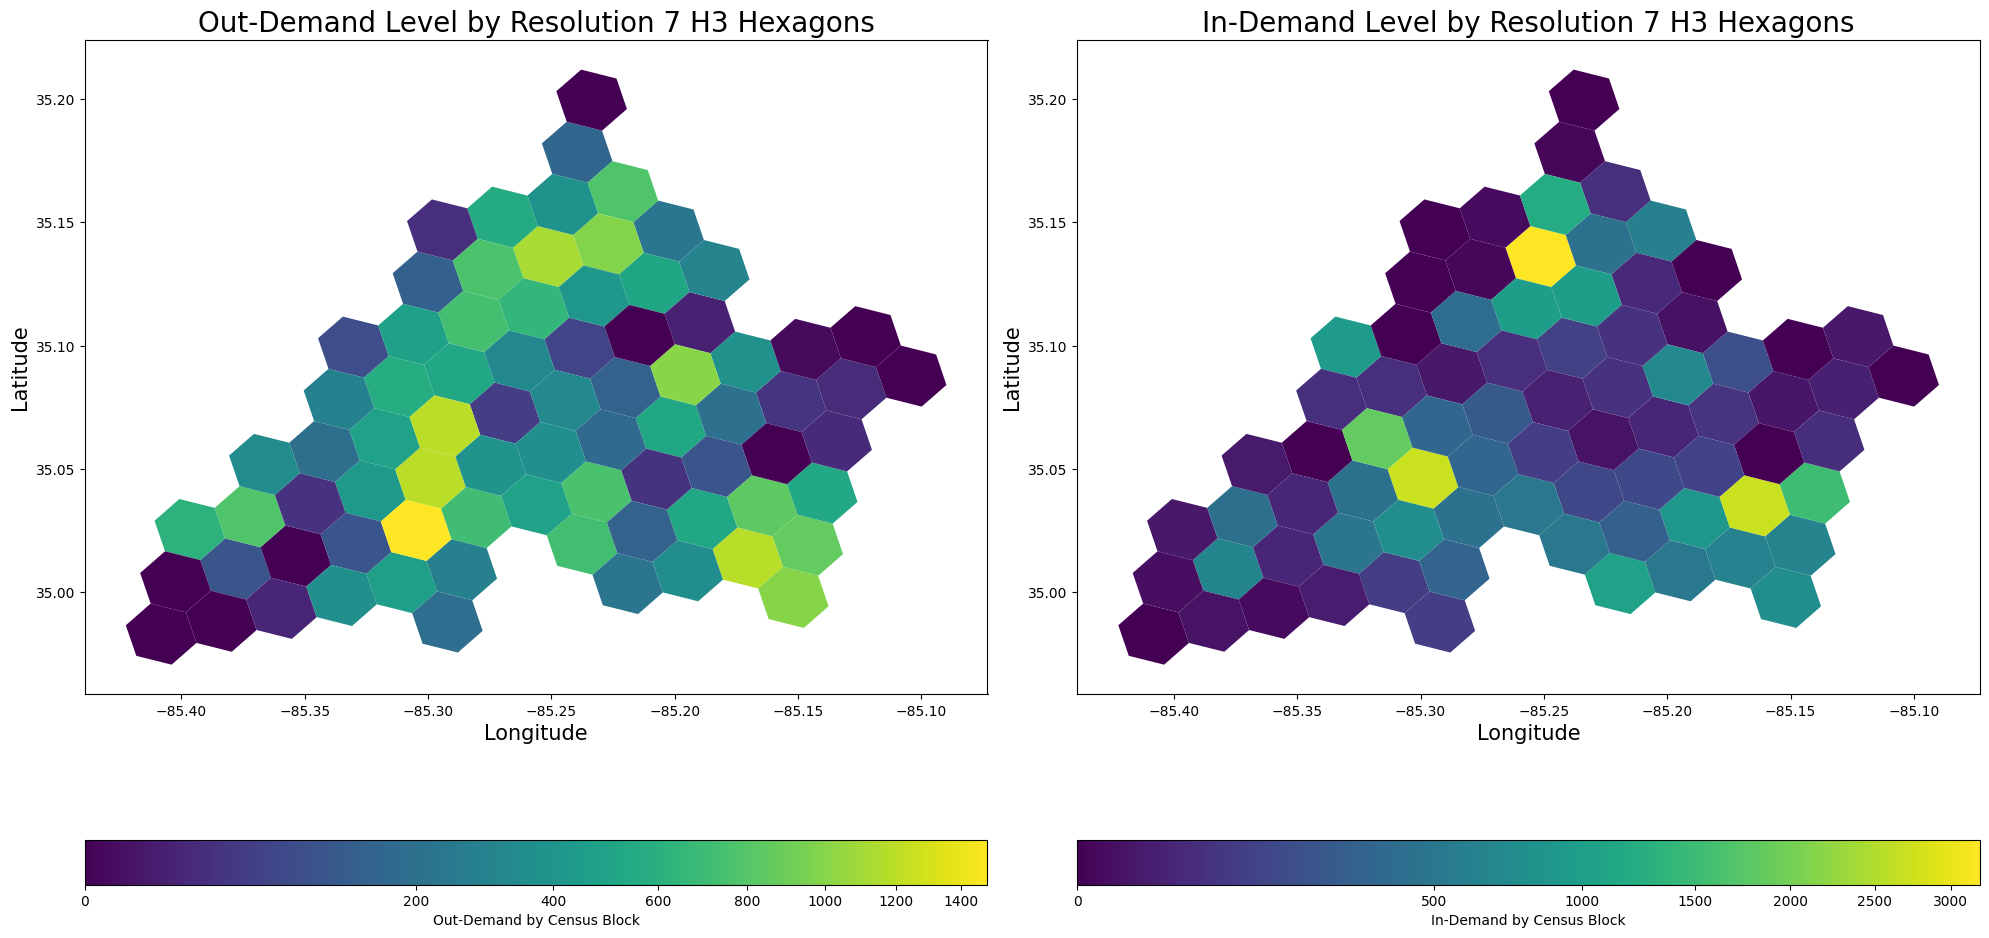

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Create a GeoDataFrame for the city boundary
boundary_gdf = gpd.GeoDataFrame(geometry=[boundary_chatt], crs='EPSG:32616')

# Out demand plot
hex_out_demand_plot = hex_gdf.plot(ax=axes[0], column='out_demand', cmap='viridis', legend=True,
                            legend_kwds={'label': "Out-Demand by Census Block", 'orientation': "horizontal"},
                            norm=PowerNorm(gamma=0.5))
# boundary_gdf.plot(ax=axes[0], edgecolor='red', facecolor='none', linewidth=1)

axes[0].set_title(f'Out-Demand Level by Resolution {resolution} H3 Hexagons', fontsize=20)
axes[0].set_xlabel('Longitude', fontsize=15)
axes[0].set_ylabel('Latitude', fontsize=15)

# In demand plot
hex_in_demand_plot = hex_gdf.plot(ax=axes[1], column='in_demand', cmap='viridis', legend=True,
                            legend_kwds={'label': "In-Demand by Census Block", 'orientation': "horizontal"},
                            norm=PowerNorm(gamma=0.5))
# boundary_gdf.plot(ax=axes[1], edgecolor='red', facecolor='none', linewidth=1)

axes[1].set_title(f'In-Demand Level by Resolution {resolution} H3 Hexagons', fontsize=20)
axes[1].set_xlabel('Longitude', fontsize=15)
axes[1].set_ylabel('Latitude', fontsize=15)

plt.tight_layout()
plt.show()

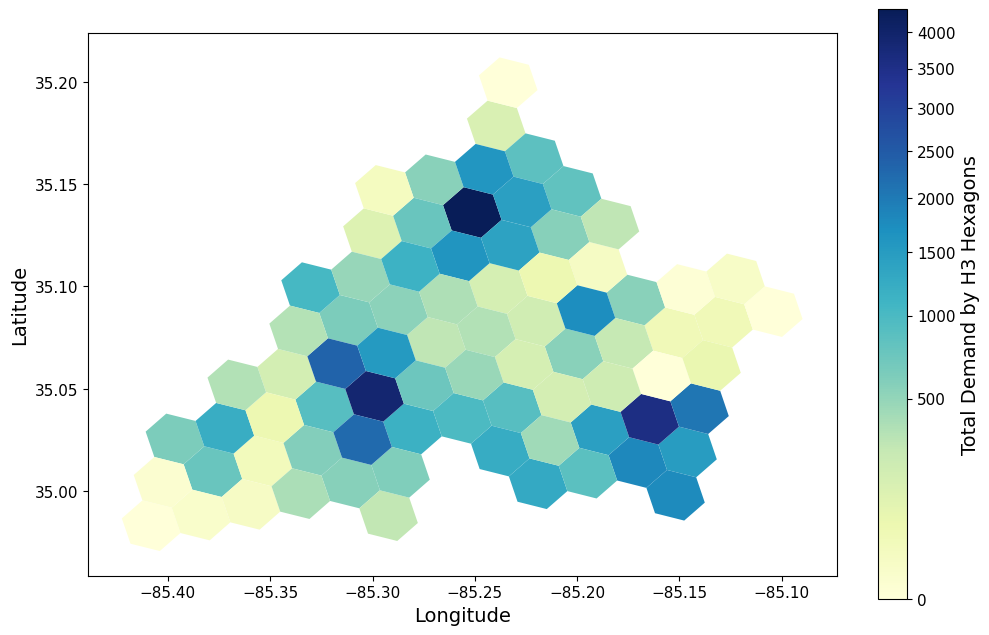

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Create total demand column
hex_gdf['total_demand'] = hex_gdf['in_demand'] + hex_gdf['out_demand']

# Set up figure and axis
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Define colormap and norm
cmap = plt.get_cmap('YlGnBu')
norm = PowerNorm(gamma=0.5, vmin=hex_gdf['total_demand'].min(), vmax=hex_gdf['total_demand'].max())

# Plot without automatic legend
hex_gdf.plot(ax=ax, column='total_demand', cmap=cmap, norm=norm)

# Manually add a tighter colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []  # dummy array for colorbar
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.036, pad=0.05)
cbar.set_label("Total Demand by H3 Hexagons", fontsize=14)
cbar.ax.tick_params(labelsize=11) 

# Titles and labels
# ax.set_title(f'Total Demand Level by Resolution {resolution} H3 Hexagons', fontsize=20)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=11) 

plt.tight_layout()
plt.savefig("demand_vis.png", dpi=600, bbox_inches='tight')
plt.show()


In [9]:
len(hex_gdf)

78

### Construct the graph for the H3 system

In [10]:
H_hex = construct_block_graph(hex_gdf, G)

### Pre-compute shortest paths

In [7]:
# def pre_compute_center_distance(H_hex, G):
    
#     center_distance = defaultdict(lambda: defaultdict(str))
#     block_pairs = [(b1, b2) for b1 in H_hex.nodes for b2 in H_hex.nodes]
    
#     for b1, b2 in tqdm(block_pairs, desc="Computing center distances"):
#         if b1 == b2:
#             center_distance[b1][b2] = 0
#         else:
#             n1 = H_hex.nodes[b1]['center_node']
#             n2 = H_hex.nodes[b2]['center_node']
#             if not nx.has_path(G, n1, n2):
#                 center_distance[b1][b2] = np.inf
#                 continue
#             center_distance[b1][b2] = nx.shortest_path_length(G, source=n1, target=n2, weight='travel_time')
    
#     return center_distance

# center_distances = pre_compute_center_distance(H_hex, G)


In [11]:
with open(f'data/hex_{resolution}_center_distances_chatt.json', 'r') as f:
    center_distances = json.load(f)

### Check the demand and distance statistics

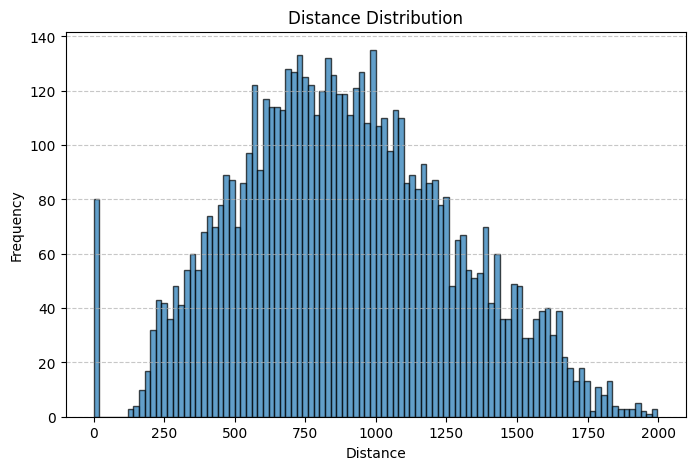

In [12]:
center_distances_list = [v for inner in center_distances.values() for v in inner.values() if not np.isinf(v)]
max_distance = max(center_distances_list)


# Visualize the histogram
plt.figure(figsize=(8, 5))
plt.hist(center_distances_list, bins=100, edgecolor='black', alpha=0.7)  # Adjust bin count as needed
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distance Distribution')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

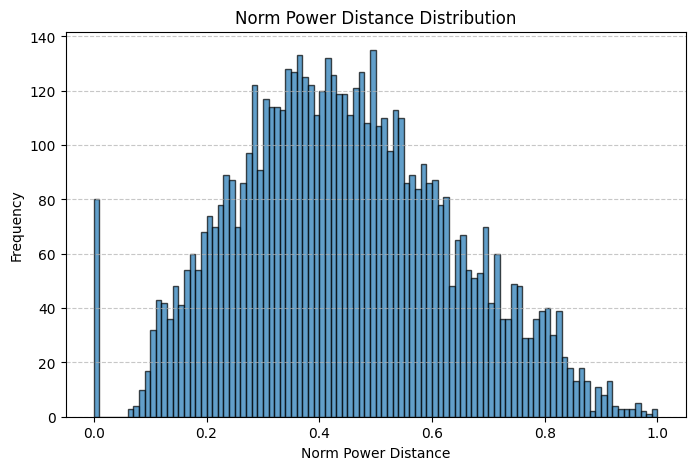

In [13]:
# Normalize the shortest path distances
power = 1
norm_max = 1
norm_square_center_distances = {
    outer_key: {inner_key: ((norm_max * value / max_distance)**power if not np.isinf(value) else np.inf)
                for inner_key, value in inner_dict.items()}
    for outer_key, inner_dict in center_distances.items()
}

norm_square_center_distances_list = [v for inner in norm_square_center_distances.values() for v in inner.values() if not np.isinf(v)]

# Visualize the histogram
plt.figure(figsize=(8, 5))
plt.hist(norm_square_center_distances_list, bins=100, edgecolor='black', alpha=0.7)  # Adjust bin count as needed
plt.xlabel('Norm Power Distance')
plt.ylabel('Frequency')
plt.title('Norm Power Distance Distribution')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

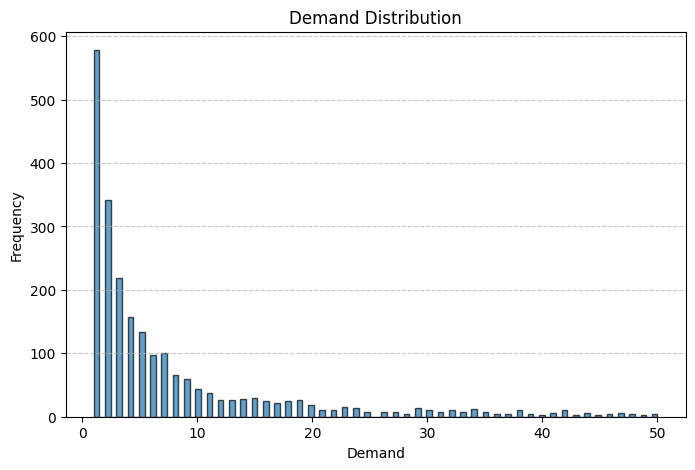

The total demand is:  30506
The total demand under 50 is:  17119


In [14]:
demand_list = [v for inner in demand.values() for v in inner.values()]
truncated_demand_list = [v for inner in demand.values() for v in inner.values() if v <= 50 and v > 0]

# Visualize the histogram
plt.figure(figsize=(8, 5))
plt.hist(truncated_demand_list, bins=100, edgecolor='black', alpha=0.7)  # Adjust bin count as needed
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.title('Demand Distribution')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate all the demand
total_demand = sum(demand_list)
print("The total demand is: ", total_demand)
total_demand_under_50 = sum(truncated_demand_list)
print("The total demand under 50 is: ", total_demand_under_50)

### Solving the zoning problem using SimpleZoning algoithm

In [43]:
from utils_itsc import baseline_A, calculate_total_demand_served

NUM_ZONES = 2
MAX_DIAMETER = 480

selected_zones_baseline = baseline_A(H_hex, demand, MAX_DIAMETER, center_distances, NUM_ZONES)
print("Selected zones:", selected_zones_baseline)
demand_served_baseline =  calculate_total_demand_served(selected_zones_baseline, demand)
print("Total demand served:", demand_served_baseline)


No more candidate nodes to be added. Complete the expansion for zone 0
No more candidate nodes to be added. Complete the expansion for zone 1
Selected zones: [{'8744cd5a2ffffff', '8744cd5aeffffff', '8744cd5a0ffffff', '8744cd5a1ffffff', '8744cd5a6ffffff', '8744cd584ffffff', '8744cd5a3ffffff'}, {'8744cd59bffffff', '8744cd59dffffff', '8744cd599ffffff', '8744cd4a6ffffff', '8744cd4a4ffffff', '8744cd598ffffff'}]
Total demand served: 7902


### Solving the zoning problem using CliqueGen + ZoningILP

In [44]:
from utils_itsc import calculate_total_demand_served, clique_generator_on_map, solve_ILP


NUM_ZONES = 2
MAX_DIAMETER = 480
CONNECTIVITY = 1

lst, cardinality = clique_generator_on_map(H_hex, MAX_DIAMETER, center_distances, CONNECTIVITY)

print(len(lst))
print("Highest Cardinality", cardinality)


selected_zones_our = solve_ILP(H_hex, lst, demand, NUM_ZONES)
print("Selected zones:", selected_zones_our)
demand_served_our = calculate_total_demand_served(selected_zones_our, demand)
print("Total demand served:", demand_served_our)

Cardinality 2 has 375 cliques
Cardinality 2 complete
Cardinality 3 has 541 cliques
Cardinality 3 complete
Cardinality 4 has 493 cliques
Cardinality 4 complete
Cardinality 5 has 303 cliques
Cardinality 5 complete
Cardinality 6 has 121 cliques
Cardinality 6 complete
Cardinality 7 has 30 cliques
Cardinality 7 complete
Cardinality 8 has 4 cliques
Cardinality 8 complete
Cardinality 9 has 0 cliques
Cardinality 9 complete
0 duplicates found
1945
Highest Cardinality 8
Set parameter Username
Set parameter LicenseID to value 2654751
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2654733
Academic license 2654733 - for non-commercial use only - registered to rk___@cornell.edu
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: 13th Gen Intel(R) Core(TM) i7-1355U, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Academic license 2654733 - for non-commercial use

### Visualization 

In [45]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from collections import Counter

In [86]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from collections import Counter
import numpy as np
from shapely.geometry import Polygon
import pandas as pd

def visualize_zones_in_hex(zones_1, demand_served_1, zones_2, demand_served_2, hex_gdf):
    """
    1 is for baseline
    2 is for our algorithm
    """
    
    
    # Define a list of distinct colors
    colors = list(mcolors.TABLEAU_COLORS.values())

    # Create a plot
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot all hexagons in gray
    hex_gdf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)

    # Store legend handles
    legend_handles = []

    # Store all hex ids for overlap detection
    all_hex_ids = []  # To track frequency of each hex
    updated_geometries = []

    # Plot each selected zone from the first algorithm
    for i, hex_set in enumerate(zones_1):
        subset_hex_gdf = hex_gdf.loc[list(hex_set)]
        color = colors[i % len(colors)]  # Use modulo for color assignment
        subset_hex_gdf.plot(ax=ax, color=color, edgecolor='black', alpha=0.8)
        legend_handles.append(mpatches.Patch(color=color, label=f"SimpleZoning"))
        all_hex_ids.extend(hex_set)  # Track hex ids for overlap

    # Plot each selected zone from the second algorithm
    for i, hex_set in enumerate(zones_2):
        subset_hex_gdf = hex_gdf.loc[list(hex_set)]
        color = colors[(i + len(zones_1)) % len(colors)]  # Offset the color index for Algo 2
        subset_hex_gdf.plot(ax=ax, color=color, edgecolor='black', alpha=0.8)
        legend_handles.append(mpatches.Patch(color=color, label=f"Our Framework"))
        all_hex_ids.extend(hex_set)  # Track hex ids for overlap

    # Identify overlapping cells
    hex_freq = Counter(all_hex_ids)
    overlapping_ids = [hex_id for hex_id, count in hex_freq.items() if count > 1]

    if overlapping_ids:
        overlapping_hexes = hex_gdf.loc[overlapping_ids]

        # Plot overlapping cells with half-and-half coloring and update hex_gdf
        for hex_id in overlapping_ids:
            # Find which zones this hexagon belongs to
            overlapping_zone_1 = [i for i, hex_set in enumerate(zones_1) if hex_id in hex_set]
            overlapping_zone_2 = [i for i, hex_set in enumerate(zones_2) if hex_id in hex_set]

            # Get the corresponding colors for the zones that overlap
            color_1 = colors[overlapping_zone_1[0] % len(colors)] if overlapping_zone_1 else None
            color_2 = colors[overlapping_zone_2[0] + len(zones_1) % len(colors)] if overlapping_zone_2 else None

            if color_1 and color_2:
                subset_hex_gdf = hex_gdf.loc[[hex_id]]

                # Get hexagon geometry (the exterior of the polygon)
                hex_patch = subset_hex_gdf.geometry.iloc[0]

                # Get hexagon vertices and calculate the center
                vertices = np.array(hex_patch.exterior.coords)
                center = np.mean(vertices, axis=0)

                # Draw the hexagon outline
                ax.add_patch(mpatches.Polygon(
                    hex_patch.exterior.coords, facecolor='none', edgecolor='black', linewidth=1))

                # Split the hexagon into two halves, each with one color
                for i in range(3):  # First three vertices for one half
                    x, y = vertices[i]
                    x_next, y_next = vertices[(i + 1) % 6]
                    ax.add_patch(mpatches.Polygon(
                        [(center[0], center[1]), (x, y), (x_next, y_next)],
                        closed=True, facecolor=color_1, edgecolor='none', alpha=0.8))

                for i in range(3, 6):  # Last three vertices for the other half
                    x, y = vertices[i]
                    x_next, y_next = vertices[(i + 1) % 6]
                    ax.add_patch(mpatches.Polygon(
                        [(center[0], center[1]), (x, y), (x_next, y_next)],
                        closed=True, facecolor=color_2, edgecolor='none', alpha=0.8))

                # Update the hex_gdf to include the new split hexagon geometries
                new_geom_1 = Polygon([(center[0], center[1]), (vertices[0][0], vertices[0][1]), (vertices[1][0], vertices[1][1])])
                new_geom_2 = Polygon([(center[0], center[1]), (vertices[3][0], vertices[3][1]), (vertices[4][0], vertices[4][1])])

                updated_geometries.append(new_geom_1)
                updated_geometries.append(new_geom_2)

        # Update hex_gdf with the new geometries for overlapping zones
        hex_gdf = pd.concat([hex_gdf, pd.DataFrame({
            'geometry': updated_geometries
        })], ignore_index=True)

    # Legend for overlapping cells
    # legend_handles.append(mpatches.Patch(edgecolor='black', facecolor='none', linestyle='--', linewidth=2, label='Overlapping Cell'))

    # Add labels and legend
    ax.set_xlabel("Longitude", fontsize=14)
    ax.set_ylabel("Latitude", fontsize=14)
    legend = ax.legend(handles=legend_handles, title="Zones", loc='best', fontsize=14)
    legend.get_title().set_fontsize('14')

    # Add total demand annotations (replace with actual values)
    ax.text(
        0.05, 0.95,
        f"Total Demand Served",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray")
    )
    ax.text(
        0.05, 0.89,
        f"SimpleZoning: {demand_served_2:,}",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray")
    )

    ax.text(
        0.05, 0.83,
        f"CliqueGen + ZoningILP: {demand_served_1:,}",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray")
    )
    
    ax.tick_params(axis='both', labelsize=12)

    fig.savefig("optimal_zones.png", dpi=600, bbox_inches='tight')
    plt.show()


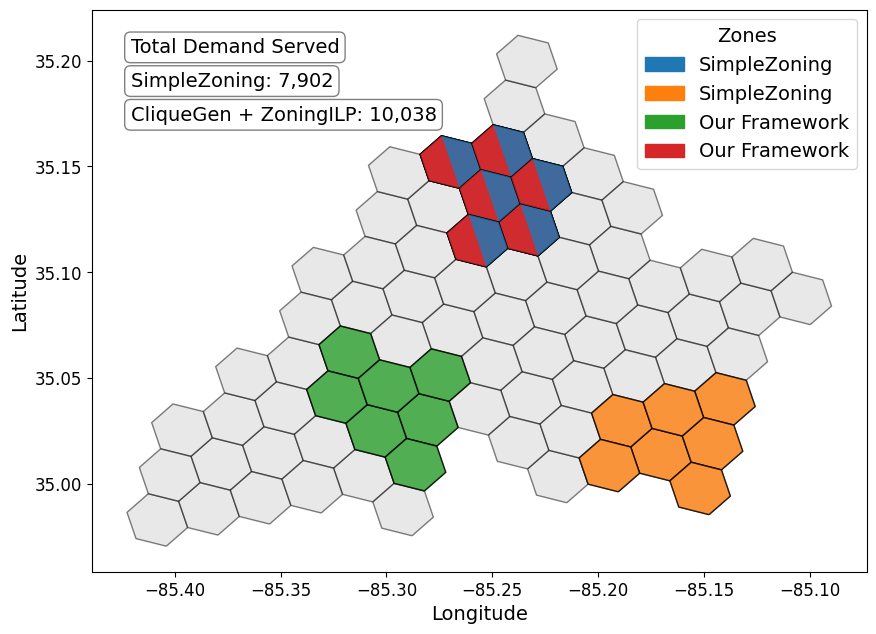

In [87]:
# Example call to the function with two algorithms' zones
visualize_zones_in_hex(selected_zones_our, demand_served_our, selected_zones_baseline, demand_served_baseline, hex_gdf)

### Solve the zoning problem using CG

In [ ]:
from algos import column_generation

ALPHA = 10
BETA = 1
BUDGET = 5
NUM_COLS = 3
NUM_RUNS = 5
METHOD = 'random_init'
CG_TL = 600
PRICING_TL = 60

zones, columns, duals, master_LP_objs = column_generation(list(H_hex.nodes), budget=BUDGET, demand=demand, 
                                                        distances=norm_square_center_distances,
                                                        alpha=ALPHA, beta=BETA,
                                                        num_columns=NUM_COLS,
                                                        cg_time_limit=CG_TL,
                                                        pricing_time_limit=PRICING_TL,
                                                        pricing_method=METHOD,
                                                        num_random_runs=NUM_RUNS)

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: 13th Gen Intel(R) Core(TM) i7-1355U, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 303051 rows, 303051 columns and 308903 nonzeros
Model fingerprint: 0x96cab36c
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [1e+00, 2e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [6e-08, 5e+01]
Presolve removed 303051 rows and 303051 columns
Presolve time: 0.09s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.8032108e+03   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.16 seconds (0.15 work units)
Optimal objective  4.803210830e+03
Number of degenerate variables: 0
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Iteration 0: Objective = 4803.210830288781
lambda = 0.0
sum_of_pi = 26754

In [ ]:
# Verify that each column generated is unique (no cycling), meaning CG is working correctly, though not necessarily efficient
columns_frozen = [frozenset(columns[i][0]) for i in columns.keys()]
has_duplicates = len(columns_frozen) != len(set(columns_frozen))
print("Has duplicate columns: ", has_duplicates)

print("Number of columns:", len(columns_frozen))
print("Number of distinct columns:", len(set(columns_frozen)))

Has duplicate columns:  True
Number of columns: 82
Number of distinct columns: 81


/tmp/ipykernel_403095/612699780.py:21: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipykernel_403095/612699780.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


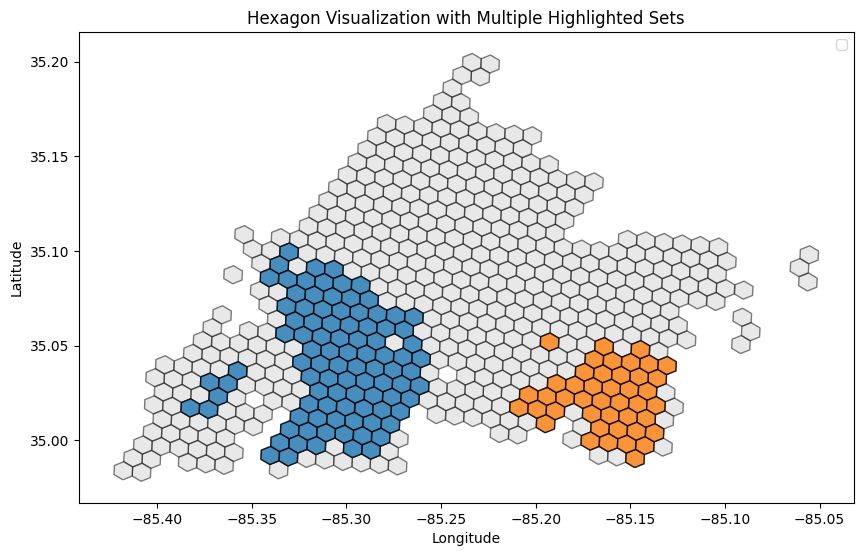

In [ ]:
import matplotlib.colors as mcolors

# Define a list of colors (modify if needed)
colors = list(mcolors.TABLEAU_COLORS.values())  # Get distinct colors from Matplotlib

# Create a plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot all hexagons in gray as the base layer
hex_gdf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)

# Iterate through the sets and plot each in a different color
for i, hex_set in enumerate(zones):
    subset_hex_gdf = hex_gdf.loc[list(hex_set)]  # Convert set to list and filter
    subset_hex_gdf.plot(ax=ax, color=colors[i % len(colors)], edgecolor='black', alpha=0.8, label=f"Group {i+1}")

# Titles and labels
ax.set_title("Hexagon Visualization with Multiple Highlighted Sets")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

plt.show()


In [ ]:
def evaluate_zoning(zones, demand):
    total_demand = 0
    for zone in zones:
        for i in zone:
            for j in zone:
                total_demand += demand[i][j]
    return total_demand

TT_demand = evaluate_zoning(zones, demand)
print("The total demand served is: ", TT_demand)

The total demand served is:  9323
